# Diversity provenance and comparison

This notebook compares the paper-derived `diversity.standardized` values in `data/sully_og/data_for_maps.csv` with standardized species-richness values from `data/ecoregion_diversity/ecoregions.csv`.

It also documents where `diversity.standardized` is produced and propagated in the original and current code paths.

## Where `diversity.standardized` Comes From

Original paper code path in `src/native_r/1_run_the_beta_model.Rmd`:

1. Lines 158-160 define `standardize_function(x) = (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)`.
2. Line 168 creates `diversity$diversity.standardized <- standardize_function(diversity$SpeciesAccepted)` from `coral_diversity_for_coral_cover.csv`.
3. Lines 176-178 build `sites_and_region_df` and join `diversity.standardized` by ecoregion name (`ERName`).
4. Line 183 joins that site/ecoregion table back onto `data` by `Reef_ID`.
5. Lines 199-207 pass `diversity = diversity$diversity.standardized` into the JAGS data list.
6. Line 738 writes the enriched `data` object to `data_for_maps.csv`, preserving `diversity.standardized`.

Updated R reproduction path in `src/native_r/my_1_run_the_beta_model.Rmd`:

1. Line 151 reads `data_for_maps.csv` as the trusted mapping.
2. Lines 152-158 extract `Reef_ID`, trusted ecoregion/ERG, and `diversity.standardized`.
3. Lines 161-163 join the trusted mapping onto the freshly spatial-joined coral-cover data by `Reef_ID`.
4. Line 212 filters out rows where `diversity.standardized` is missing.

Python model-ready path:

1. `src/dataloading/build_sully_model_ready_data.py` lines 134-139 require `diversity.standardized` in `data_for_maps.csv`.
2. Lines 153-155 rename it to `_trusted_diversity` during the trusted lookup join.
3. Lines 222-224 write `_trusted_diversity` back to `out["diversity.standardized"]`.
4. Lines 95-102 require non-missing `diversity.standardized` in the final model-ready filter.
5. `src/models/hbb/indices.py` lines 42, 68-72, 109, and 140-145 use `diversity.standardized` to build the ecoregion-level diversity vector passed to the PyMC model.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from src import config
from src.processing import processdata
from src.dataloading import diversity


# Diversity datasets


### [Coral trait database](https://www.coraltraits.org/)

Various (of varying availability) geographical, morphological, phylogenetic, and physiological data from various combined observations. Appears to be no files for geographical range (specify only the lat/lon edges of range), although some species have a map.

Not a priority

### [Reef Life Survey](https://reeflifesurvey.com/survey-data/) now hosted on [Australian Ocean Data Network](https://portal.aodn.org.au/search)

AODN is a cool site in general and something to be aware of! Various datasets including remote sensed observations of coastal ecosystems.

RLS says there are ‘habitat quadrats’ but appears more focussed on fish. This is apparently the ‘IMOS - National Reef Monitoring Network Sub-Facility - Global benthic cover data (photoquadrat image annotations)’  https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/0a65be6d-1c76-49ac-a151-80acf123612c page but can find no actual way to download this. Recently updated page, so check back later

N.B. using COTW ecoregions for now to compare with Sully's paper.

For my paper, use MEOW ecoregions to standardise with usual discussions, and because COTW shapefiles/names have changed slightly.


### [Ocean Biodiversity Information System](https://obis.org/data/access/)

Meta-dataset of biodiversity point-data. Very cool-looking record. Python package for interfacing here: https://github.com/iobis/pyobis. Can sum species information across MEOWs and compare with Veron!!


```
from pyobis import occurrences

# Search for occurrences
query = occurrences.search(scientificname="Mola mola")
data = query.execute()

# Get occurrence by ID
query = occurrences.get(id="00003cf7-f2fc-4c53-98a6-7d846e70f5d1")
data = query.execute()
```

Will need a list of relevant spices. For now using ‘Anthozoa’ (sub-phylum/class containing corals and sea anemones).

N.B. WORMS uses OBIST data for their distribution documentation: https://www.marinespecies.org/aphia.php?p=taxdetails&id=1292#distributions


In [2]:
obis_df = pd.read_csv(
    config.diversity_dir / "obis_anthozoa.csv",
    low_memory=False,
).rename(columns=str.lower)
obis_df.head()

,unnamed: 0,associatedreferences,basisofrecord,brackish,class,classid,coordinateuncertaintyinmeters,datasetid,date_end,date_mid,...,parentnameusage,pointradiusspatialfit,genericname,subvariety,subvarietyid,verbatimlabel,associatedorganisms,earliestepochorlowestseries,formation,lowestbiostratigraphiczone
0,0,"Jacobsen Stout, N., L. Kuhnz, L. Lundsten, B. ...",MachineObservation,False,Octocorallia,1341.0,100.0,MBARI,7.826112e+11,7.826112e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"Yoklavich MM, Laidig T, Taylor A, Watters D, K...",MachineObservation,NaN,Octocorallia,1341.0,100.0,NOAA_VO-10-10,1.286410e+12,1.286410e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,HumanObservation,NaN,Hexacorallia,1340.0,25.0,NaN,1.528848e+12,1.528848e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,HumanObservation,NaN,Hexacorallia,1340.0,200.0,NaN,4.666464e+11,4.666464e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"National Museum of Natural History, Smithsonia...",PreservedSpecimen,NaN,Hexacorallia,1340.0,NaN,NaN,-2.769120e+11,-2.769120e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# assign all points an ecoregion
import geopandas as gpd
from src.processing import processdata

# make into a gdf
obis_df["lat"] = obis_df["decimallatitude"]
obis_df["lon"] = obis_df["decimallongitude"]

obis_df_gdf = gpd.GeoDataFrame(
    obis_df,
    geometry=gpd.points_from_xy(obis_df["lon"], obis_df["lat"]),
    crs="EPSG:4326",
)  # assign points to meow polygons by location


In [4]:
cotw_eco_gdf = gpd.read_file(
    config.data_dir
    / "sully_og"
    / "ecoregion_shapefiles"
    / "ecoregion_exportPolygon.shp"
).rename(columns=str.lower)

In [5]:
from src.dataloading import diversity
from src.plots import plot_utils


# Use native Pacific Mercator (CM 150°) for assignment — not dateline-fixed WGS84
# reprojected to EPSG:6933, which makes Fiji etc. spuriously overlap the Pacific.


obis_df_fp = config.diversity_dir / "obis_anthozoa_cotw_ecoregions.parquet"
if not obis_df_fp.exists():
    cotw_assign_gdf = diversity.load_cotw_ecoregions_for_assignment()
    out_cotw_gdf = processdata.assign_points_to_shapes(
        obis_df_gdf,
        cotw_assign_gdf,
        cols_to_add=["erg", "ecoregion"],
        projected_crs=str(cotw_assign_gdf.crs),
    )
    print(f"Saving to {obis_df_fp}")
    out_cotw_gdf.to_parquet(obis_df_fp)
else:
    print(f"Loading from {obis_df_fp}")
    out_cotw_gdf = gpd.read_parquet(obis_df_fp)

Loading from /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/ecoregion_diversity/obis_anthozoa_cotw_ecoregions.parquet


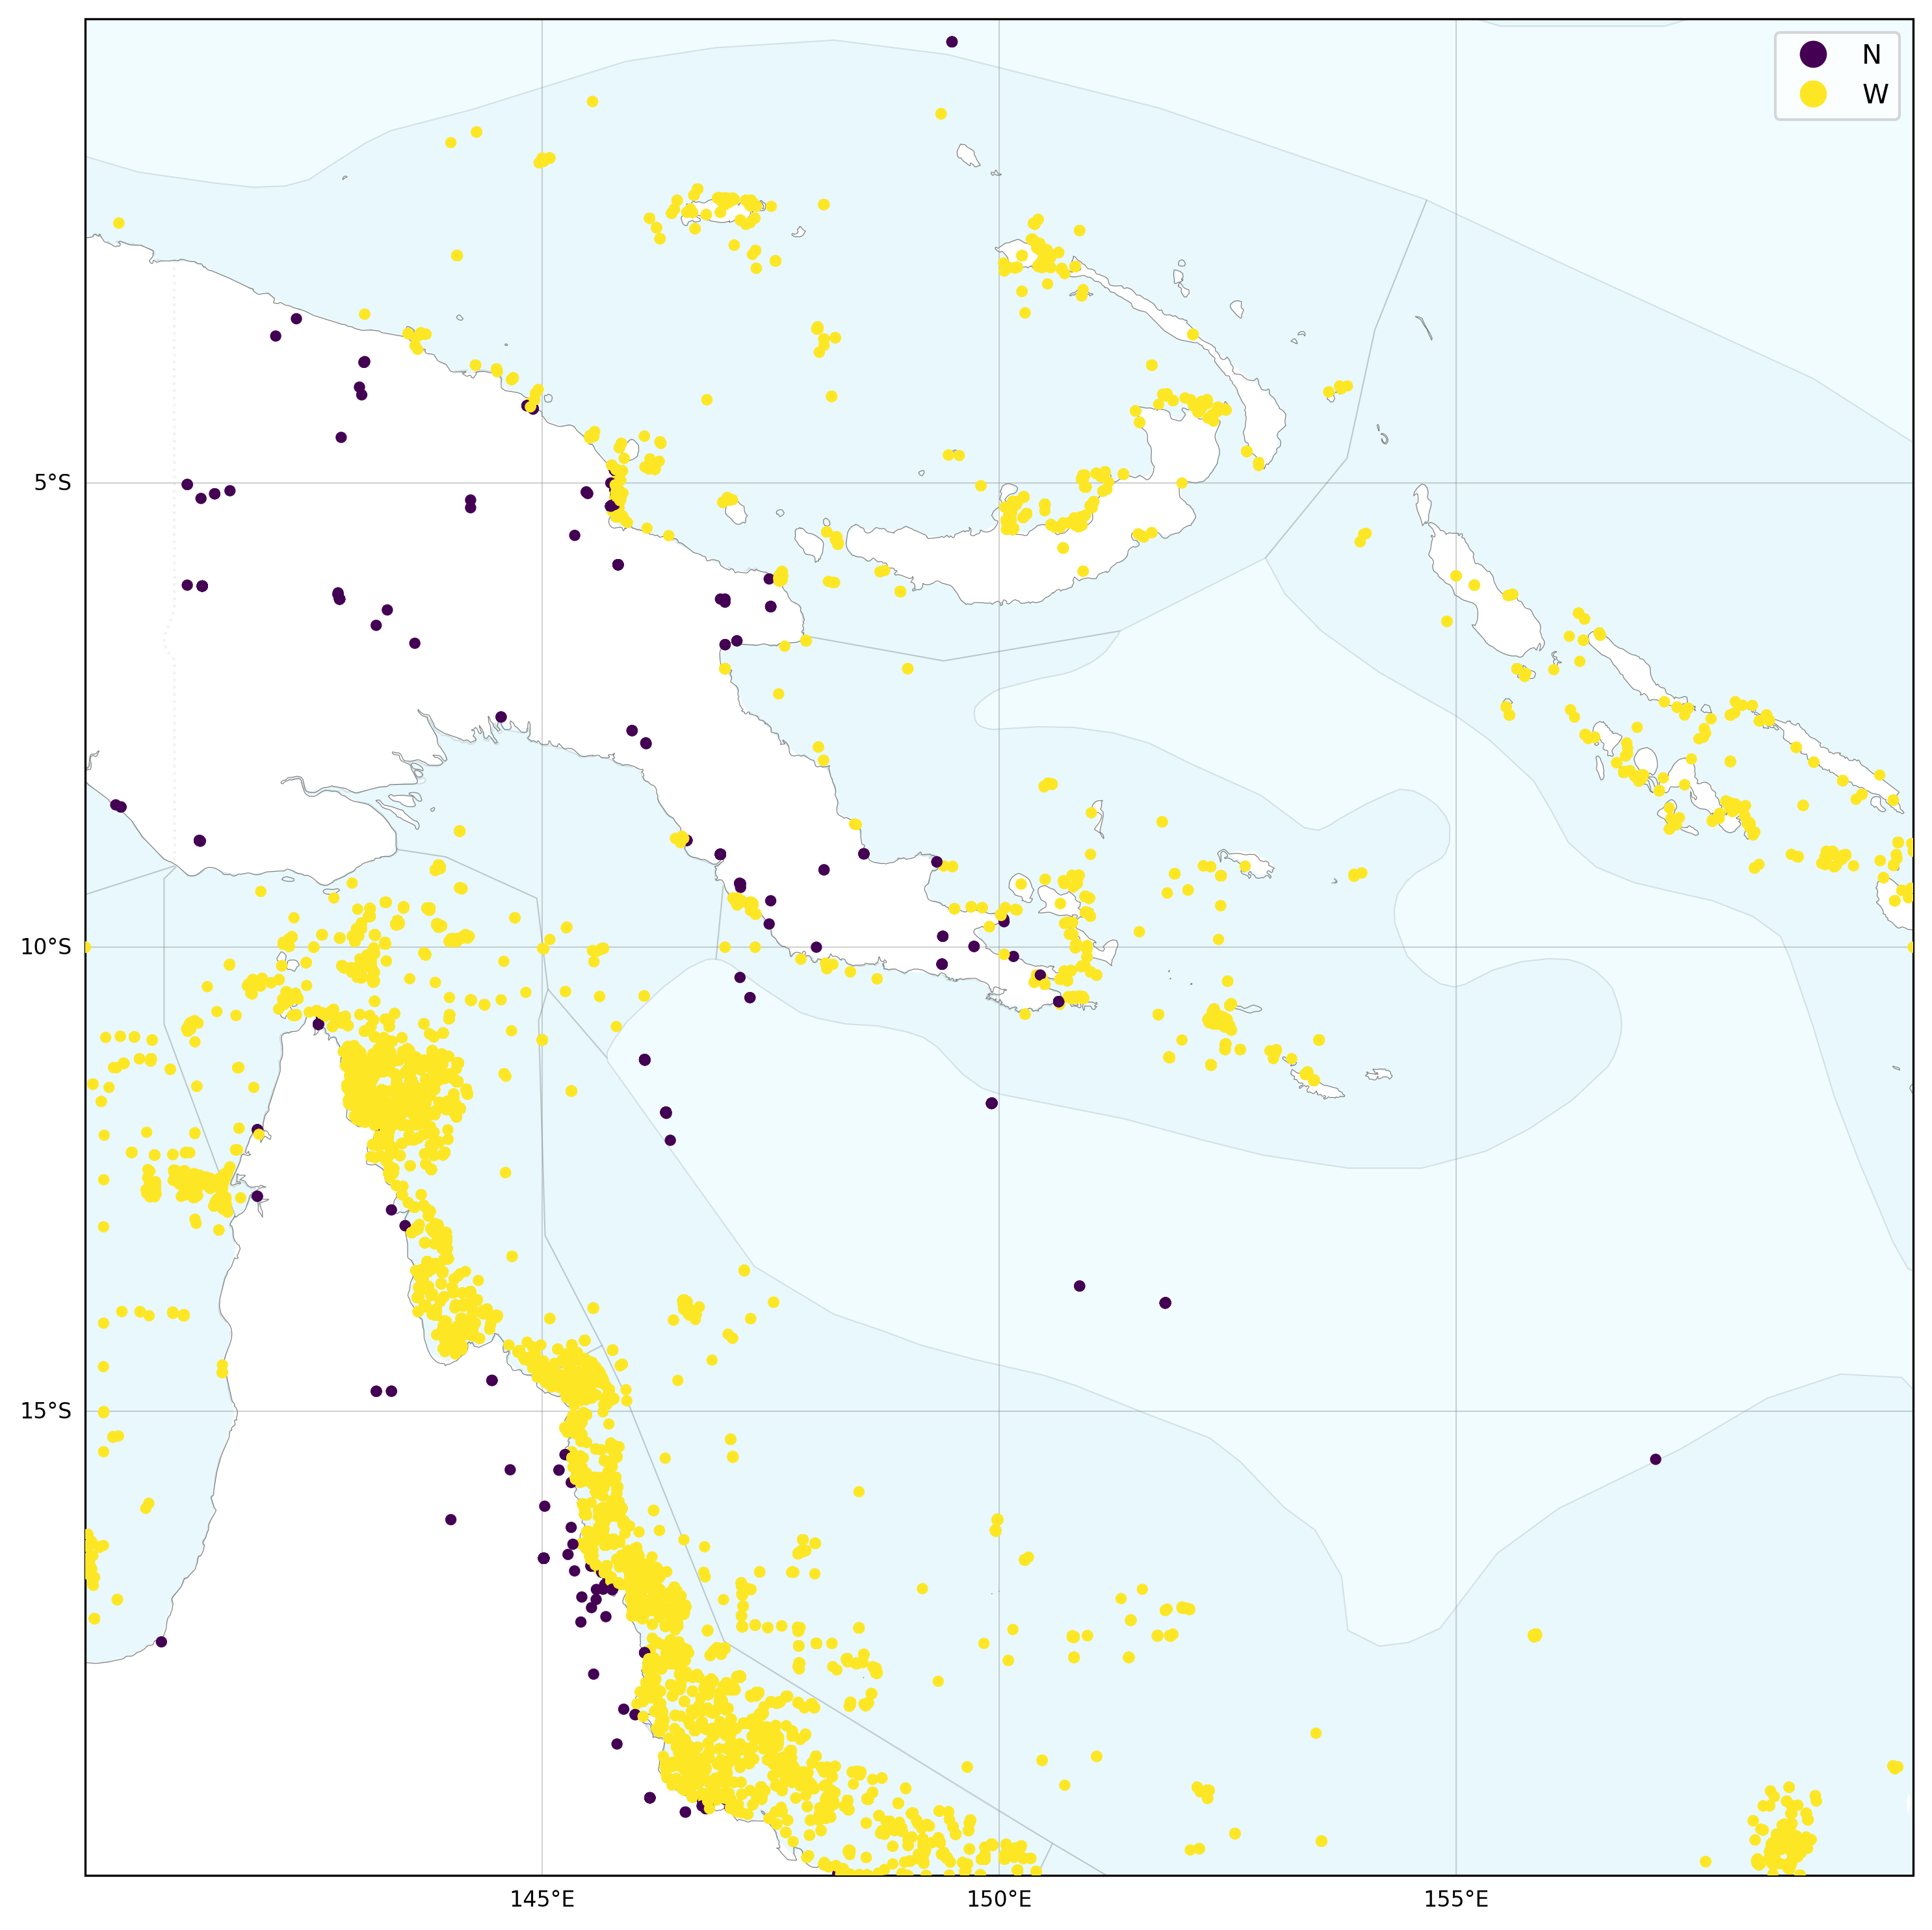

In [6]:
fig, ax = plot_utils.generate_geo_axis(central_longitude=0)


focus_lats = [-20, 0]
focus_lons = [140, 160]

cotw_plot = diversity.fix_cotw_dateline_geometries(cotw_eco_gdf)
cotw_plot.plot(
    ax=ax,
    facecolor="lightblue",
    alpha=0.1,
    edgecolor="black",
    linewidth=0.5,
    zorder=-1000,
)

plot_utils.format_geo_axis(ax)
out_cotw_gdf.cx[
    min(focus_lons) : max(focus_lons), min(focus_lats) : max(focus_lats)
].plot(
    ax=ax,
    column="shape_assign_code",
    cmap="viridis",
    legend=True,
    markersize=10,
    zorder=1100,
)
ax.set_extent([*focus_lons, *focus_lats])
fig.tight_layout()

In [7]:
nonextrap_out_cotw_gdf = out_cotw_gdf[
    out_cotw_gdf["shape_assign_code"].isin(["M", "W"])
]

In [10]:
filtered_obis_cotw_gdf.columns.to_list()


['unnamed: 0',
 'associatedreferences',
 'basisofrecord',
 'brackish',
 'class',
 'classid',
 'coordinateuncertaintyinmeters',
 'datasetid',
 'date_end',
 'date_mid',
 'date_start',
 'date_year',
 'decimallatitude',
 'decimallongitude',
 'depth',
 'eventdate',
 'family',
 'familyid',
 'genus',
 'genusid',
 'geodeticdatum',
 'individualcount',
 'kingdom',
 'kingdomid',
 'marine',
 'maximumdepthinmeters',
 'minimumdepthinmeters',
 'occurrenceid',
 'occurrencestatus',
 'order',
 'orderid',
 'phylum',
 'phylumid',
 'references',
 'scientificname',
 'scientificnameid',
 'subfamily',
 'subfamilyid',
 'subphylum',
 'subphylumid',
 'superdomain',
 'superdomainid',
 'id',
 'dataset_id',
 'node_id',
 'dropped',
 'absence',
 'originalscientificname',
 'aphiaid',
 'flags',
 'bathymetry',
 'shoredistance',
 'sst',
 'sss',
 'locality',
 'species',
 'speciesid',
 'countrycode',
 'datasetname',
 'eventid',
 'institutioncode',
 'organismquantity',
 'organismquantitytype',
 'samplingprotocol',
 'suborde

In [20]:
# remove all but scleractinia
filtered_obis_cotw_gdf = nonextrap_out_cotw_gdf[
    nonextrap_out_cotw_gdf["order"] == "Scleractinia"
]
print(
    f"Dropped {
        len(nonextrap_out_cotw_gdf[nonextrap_out_cotw_gdf['order'] != 'Scleractinia'])
    } rows"
)
n_remain = len(filtered_obis_cotw_gdf)
# remove all rows where depth is above 0 and deeper than 60m
filtered_obis_cotw_gdf = filtered_obis_cotw_gdf[filtered_obis_cotw_gdf["depth"] >= 0]
filtered_obis_cotw_gdf = filtered_obis_cotw_gdf[filtered_obis_cotw_gdf["depth"] <= 60]

# remove rows where occurencestatus is absence/not observed
filtered_obis_cotw_gdf = filtered_obis_cotw_gdf[
    ~filtered_obis_cotw_gdf["occurrencestatus"].isin(["absence", "not observed"])
]
# remove rows where absence is true
filtered_obis_cotw_gdf = filtered_obis_cotw_gdf[
    filtered_obis_cotw_gdf["absence"] == False
]

print(f"Dropped {n_remain - len(filtered_obis_cotw_gdf)} rows")

# obis_biodiversity_df = nonextrap_out_cotw_gdf.groupby("ecoregion").speciesid.nunique()
obis_biodiversity_df = filtered_obis_cotw_gdf.groupby("ecoregion").speciesid.nunique()


Dropped 394302 rows
Dropped 279512 rows


In [21]:
# Standardise OBIS scientific names against WoRMS (accepted names + Aphia IDs).
filtered_obis_cotw_gdf = diversity.apply_worms_name_standardization(
    filtered_obis_cotw_gdf,
    name_col="scientificname",
    species_id_col="speciesid",
    marine_only=True,
)

worms_lookup = (
    filtered_obis_cotw_gdf[
        [
            "scientificname",
            "worms_match_count",
            "worms_match_status",
            "worms_valid_name",
            "worms_valid_aphia_id",
            "worms_match_type",
        ]
    ]
    .drop_duplicates(subset=["scientificname"])
    .rename(columns={"scientificname": "original_name"})
)

print(
    f"WoRMS matched {worms_lookup['worms_valid_name'].notna().sum():,} / "
    f"{len(worms_lookup):,} unique scientific names"
)
print(f"No match: {(worms_lookup['worms_match_status'] == 'no_match').sum():,}")
print(f"Ambiguous matches: {(worms_lookup['worms_match_count'] > 1).sum():,}")

name_changes = worms_lookup.loc[
    worms_lookup["worms_valid_name"].notna()
    & worms_lookup["original_name"].ne(worms_lookup["worms_valid_name"])
].sort_values("original_name")
print(f"Names mapped to a different accepted name: {len(name_changes):,}")
display(name_changes.head(20))

obis_biodiversity_df = filtered_obis_cotw_gdf.groupby("ecoregion")[
    "speciesid_standardized"
].nunique()


WoRMS name lookup:   0%|          | 0/23 [00:00<?, ?batch/s]

WoRMS matched 1,116 / 1,123 unique scientific names
No match: 5
Ambiguous matches: 15
Names mapped to a different accepted name: 3


,original_name,worms_match_count,worms_match_status,worms_valid_name,worms_valid_aphia_id,worms_match_type
2355,Acropora valenciennesi,1,superseded combination,Acropora valenciennesii,206995.0,exact_subgenus
350479,Balanophyllia (Balanophyllia),1,accepted,Balanophyllia,135108.0,exact_subgenus
52973,Flabellum (Flabellum) transversale,1,alternative representation,Flabellum (Flabellum) transversale transversale,287028.0,exact


In [18]:
cotw_eco_df = pd.read_csv(config.data_dir / "ecoregion_diversity" / "ecoregions.csv")
cotw_eco_df

,ecoregion_name,total_species_number,QA,url,ecoregion_slug,species_url
0,Andaman Islands,340,1,https://www.coralsoftheworld.org/ecoregion_fac...,andaman-islands,https://www.coralsoftheworld.org/ecoregion_fac...
1,Andaman Sea,383,1,https://www.coralsoftheworld.org/ecoregion_fac...,andaman-sea,https://www.coralsoftheworld.org/ecoregion_fac...
2,Arabian Sea north-west,121,1,https://www.coralsoftheworld.org/ecoregion_fac...,arabian-sea-north-west,https://www.coralsoftheworld.org/ecoregion_fac...
3,Arafura Sea Islands north,526,1,https://www.coralsoftheworld.org/ecoregion_fac...,arafura-sea-islands-north,https://www.coralsoftheworld.org/ecoregion_fac...
4,Arafura Sea,270,1,https://www.coralsoftheworld.org/ecoregion_fac...,arafura-sea,https://www.coralsoftheworld.org/ecoregion_fac...
...,...,...,...,...,...,...
145,Vanuatu,391,1,https://www.coralsoftheworld.org/ecoregion_fac...,vanuatu,https://www.coralsoftheworld.org/ecoregion_fac...
146,Vietnam central,408,1,https://www.coralsoftheworld.org/ecoregion_fac...,vietnam-central,https://www.coralsoftheworld.org/ecoregion_fac...
147,Vietnam north,204,1,https://www.coralsoftheworld.org/ecoregion_fac...,vietnam-north,https://www.coralsoftheworld.org/ecoregion_fac...
148,Vietnam south,462,1,https://www.coralsoftheworld.org/ecoregion_fac...,vietnam-south,https://www.coralsoftheworld.org/ecoregion_fac...


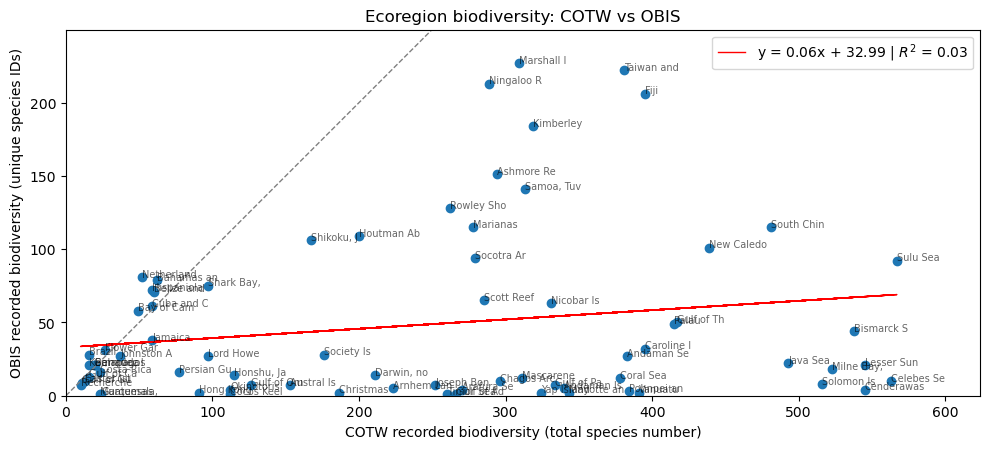

In [24]:
# get shared ecoregions
shared_ecos = set(out_cotw_gdf.ecoregion.unique()) & set(cotw_eco_gdf.ecoregion)

# For each shared ecoregion, plot a scatter of cotw vs obis biodiversity
# Build a DataFrame with both values per ecoregion
cotw_biodiv = cotw_eco_df.set_index("ecoregion_name")["total_species_number"]
obis_biodiv = obis_biodiversity_df

# Only keep shared ecoregions
scatter_df = (
    pd.DataFrame(
        {
            "cotw_biodiversity": cotw_biodiv,
            "obis_biodiversity": obis_biodiv,
        }
    )
    .dropna()
    .loc[lambda df: df.index.isin(shared_ecos)]
)

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["cotw_biodiversity"], scatter_df["obis_biodiversity"])
plt.xlabel("COTW recorded biodiversity (total species number)")
plt.ylabel("OBIS recorded biodiversity (unique species IDs)")
plt.title("Ecoregion biodiversity: COTW vs OBIS")
for ecoregion, row in scatter_df.iterrows():
    plt.annotate(
        ecoregion[:10],
        (row["cotw_biodiversity"], row["obis_biodiversity"]),
        fontsize=7,
        alpha=0.6,
    )

# plot 1:1 line
plt.plot([0, 1000], [0, 1000], color="gray", linestyle="--", linewidth=1)

slope, intercept = np.polyfit(
    scatter_df["cotw_biodiversity"], scatter_df["obis_biodiversity"], 1
)
corr = scatter_df["cotw_biodiversity"].corr(scatter_df["obis_biodiversity"])
plt.plot(
    scatter_df["cotw_biodiversity"],
    slope * scatter_df["cotw_biodiversity"] + intercept,
    color="red",
    linewidth=1,
    label=rf"y = {slope:.2f}x + {intercept:.2f} | $R^2$ = {corr**2:.2f}",
)


plt.xlim(0, max(scatter_df["cotw_biodiversity"]) * 1.1)
plt.ylim(0, max(scatter_df["obis_biodiversity"]) * 1.1)
# set axis as equal
plt.gca().set_aspect("equal", "box")
plt.legend()
plt.tight_layout()
plt.show()


## Redlist

Download from: https://www.iucnredlist.org/account (Anthozoa search)

In [22]:
es_df = pd.read_csv(
    "/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/ecoregion_diversity/ecoregion_species.csv"
)

In [23]:
from src.dataloading import diversity

redlist_gdf = diversity.load_redlist_species()
redlist_biodiversity_series = diversity.count_species_by_region(
    redlist_gdf, cotw_eco_gdf
)

print(f"Max species count: {redlist_biodiversity_series.max():.0f}")
redlist_biodiversity_series.sort_values(ascending=False).head()

redlist_biodiversity_df = redlist_biodiversity_series.reset_index(name="species_count")
redlist_biodiversity_df

Max species count: 579


,ecoregion,species_count
0,Andaman Islands,343
1,Andaman Sea,519
2,Arafura Sea,552
3,"Arnhem Land, north Australia",313
4,"Ashmore Reef, north-west Australia",551
...,...,...
145,Vanuatu,414
146,West Sumatra,512
147,Western Mexico and Revillagigedo Islands,33
148,"Western Tuamotu Archipelago, central Pacific",183


In [25]:
redlist_gdf


,assessment,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,legend,subspecies,subpop,dist_comm,island,tax_comm,geometry
0,50856395.0,50107293.0,Bunodeopsis strumosa,1,1,1,Elisa Alcazar Montanez,2015,IUCN,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((22.93222 40.64663, 22.94534 40..."
1,110517562.0,133133.0,Acropora abrolhosensis,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((144.23853 -3.82053, 144.2433 -..."
2,112092853.0,50149061.0,Ceratotrochus magnaghii,1,1,1,Elisa Alcazar Montanez,2015,IUCN,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((9.76463 43.02486, 9.76555 43.0..."
3,112093393.0,50012660.0,Spinimuricea klavereni,1,1,1,Elisa Alcazar Montanez,2015,IUCN,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((25.1804 40.85577, 25.18097 40...."
4,129471211.0,133701.0,Ctenella chagius,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((61.41996 -10.15759, 61.43331 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,213466130.0,133065.0,Tubipora musica,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((-179.53333 -12.16667, -179.715..."
906,219768301.0,219555846.0,Pocillopora grandis,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((104.48289 0.23992, 104.48289 0..."
907,219836713.0,219358889.0,Acropora muricata,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((-179.53333 -12.16667, -179.715..."
908,227494364.0,133193.0,Heliopora coerulea,1,1,1,IUCN Marine Biodiversity Unit,2024,IUCN Marine Biodiversity Unit,Extant (resident),None,None,None,None,None,"MULTIPOLYGON (((61.09998 -14.80001, 61.23276 -..."


In [26]:
redlist_gdf = diversity.apply_worms_name_standardization(
    redlist_gdf,
    name_col="sci_name",
    species_id_col="id_no",
    marine_only=True,
)


WoRMS name lookup:   0%|          | 0/19 [00:00<?, ?batch/s]

In [ ]:
# Attach geometry to redlist_biodiversity_df by merging with cotw_eco_gdf on ecoregion name
redlist_biodiversity_df = redlist_biodiversity_df.merge(
    cotw_eco_gdf[["ecoregion", "geometry"]], on="ecoregion", how="left"
)


In [ ]:
# plot spatial distribution of biodiversity



In [ ]:
import numpy as np


# get shared ecoregions
shared_ecos = set(redlist_biodiversity_df.ecoregion.unique()) & set(
    cotw_eco_gdf.ecoregion
)

# For each shared ecoregion, plot a scatter of cotw vs obis biodiversity
# Build a DataFrame with both values per ecoregion
cotw_biodiv = cotw_eco_df.set_index("ecoregion_name")["total_species_number"]
redlist_biodiv = redlist_biodiversity_df.set_index("ecoregion")["species_count"]

# Only keep shared ecoregions
scatter_df = (
    pd.DataFrame(
        {
            "cotw_biodiversity": cotw_biodiv,
            "redlist_biodiversity": redlist_biodiv,
        }
    )
    .loc[list(shared_ecos)]
    .dropna()
)

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["cotw_biodiversity"], scatter_df["redlist_biodiversity"])
plt.xlabel("COTW recorded biodiversity (total species number)")
plt.ylabel("Redlist estimated biodiversity (unique species IDs)")
plt.title("Ecoregion biodiversity: COTW vs Redlist")
for ecoregion, row in scatter_df.iterrows():
    plt.annotate(
        ecoregion[:10],
        (row["cotw_biodiversity"], row["redlist_biodiversity"]),
        fontsize=7,
        alpha=0.6,
    )

# plot 1:1 line
plt.plot([0, 1000], [0, 1000], color="gray", linestyle="--", linewidth=1)

slope, intercept = np.polyfit(
    scatter_df["cotw_biodiversity"], scatter_df["redlist_biodiversity"], 1
)
corr = scatter_df["cotw_biodiversity"].corr(scatter_df["redlist_biodiversity"])
plt.plot(
    scatter_df["cotw_biodiversity"],
    slope * scatter_df["cotw_biodiversity"] + intercept,
    color="red",
    linewidth=1,
    label=rf"$y = {slope:.2f}x + {intercept:.2f}$" + "\n" + rf"$R^2 = {corr**2:.2f}$",
)


plt.xlim(0, max(scatter_df["cotw_biodiversity"]) * 1.1)
plt.ylim(0, max(scatter_df["redlist_biodiversity"]) * 1.1)
# set axis as equal
plt.gca().set_aspect("equal", "box")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
from src.dataloading.compile_diversity import compile_diversity

(
    redlist_species_by_ecoregion,
    obis_species_by_ecoregion,
    cotw_species_by_ecoregion,
    species_presence,
    species_agreement_summary,
) = compile_diversity()

species_agreement_summary.head()

Building diversity compile (cache missing or stale)...
Loading COTW ecoregion polygons...
Loading IUCN Red List species ranges...


KeyboardInterrupt: 

In [ ]:
data_for_maps = pd.read_csv(DATA_FOR_MAPS)
ecoregions = pd.read_csv(ECOREGIONS)

ecoregions["total_species_number"] = pd.to_numeric(
    ecoregions["total_species_number"], errors="coerce"
)
ecoregions["ecoregions_diversity_standardized"] = (
    ecoregions["total_species_number"] - ecoregions["total_species_number"].mean()
) / ecoregions["total_species_number"].std()
ecoregions["norm_name"] = ecoregions["ecoregion_name"].map(norm_name)

paper_div = (
    data_for_maps[["Ecoregion.y", "diversity.standardized"]]
    .dropna()
    .drop_duplicates()
    .groupby("Ecoregion.y", as_index=False)
    .agg(
        paper_diversity_standardized=("diversity.standardized", "first"),
        n_values=("diversity.standardized", "nunique"),
    )
)
paper_div["alias_name"] = paper_div["Ecoregion.y"].map(lambda x: ALIASES.get(x, x))
paper_div["norm_name"] = paper_div["alias_name"].map(norm_name)

comparison = paper_div.merge(
    ecoregions[
        [
            "ecoregion_name",
            "norm_name",
            "total_species_number",
            "ecoregions_diversity_standardized",
        ]
    ],
    on="norm_name",
    how="left",
)
comparison["difference"] = (
    comparison["ecoregions_diversity_standardized"]
    - comparison["paper_diversity_standardized"]
)
comparison["abs_difference"] = comparison["difference"].abs()

print(f"data_for_maps ecoregions: {paper_div['Ecoregion.y'].nunique()}")
print(f"matched to ecoregions.csv: {comparison['ecoregion_name'].notna().sum()}")
print(f"unmatched: {comparison['ecoregion_name'].isna().sum()}")
if len(comparison) > 0:
    comparison.loc[comparison["ecoregion_name"].isna(), ["Ecoregion.y", "alias_name"]]


In [ ]:
comparison[
    [
        "Ecoregion.y",
        "ecoregion_name",
        "paper_diversity_standardized",
        "total_species_number",
        "ecoregions_diversity_standardized",
        "difference",
        "abs_difference",
    ]
].sort_values("abs_difference", ascending=False).head(20)


In [ ]:
matched = comparison.dropna(
    subset=["ecoregions_diversity_standardized", "paper_diversity_standardized"]
).copy()
corr = matched["paper_diversity_standardized"].corr(
    matched["ecoregions_diversity_standardized"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(
    data=matched,
    x="paper_diversity_standardized",
    y="ecoregions_diversity_standardized",
    ax=axes[0],
    scatter_kws={"s": 35, "alpha": 0.8},
    line_kws={"color": "red"},
)
axes[0].axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1)
axes[0].set_title(f"Standardized diversity comparison (r = {corr:.2f})")
axes[0].set_xlabel("data_for_maps diversity.standardized")
axes[0].set_ylabel("ecoregions.csv standardized species count")

sns.histplot(matched["difference"], bins=100, ax=axes[1])
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("ecoregions.csv - data_for_maps")
axes[1].set_xlabel("Difference in standardized diversity")
axes[1].set_yscale("log")
fig.tight_layout()
plt.show()


## Ecoregion map (MEOW + paper assignment)

In [ ]:
# Paper-faithful vs robust index assignment — side-by-side comparison

from src.dataloading.build_sully_model_ready_data import build_sully_model_ready_data
from src.models.hbb.indices import (
    prepare_hierarchical_indices_legacy,
    prepare_hierarchical_indices_reparam,
)
import geopandas as gpd

from src.dataloading.build_sully_model_ready_data import (
    _apply_trusted_mapping,
    _filter_pre_mapping,
    _spatial_join_ecoregions,
    diversity_lookup_path,
)

from src.models.hbb.run_investigation import r_lexicographic_factor_codes

DATA_DIR = ROOT / "data" / "sully_og"

# ── Layer 1: data-cache assignment (build_sully_model_ready_data) ─────────────────
# paper_factor: trusted data_for_maps join, then assign_paper_site_region_indices
#               (R: as.numeric(as.factor(Reef_ID/Ecoregion)) on filtered data)
# data_for_maps: keep frozen site/region from data_for_maps.csv (dense reparam path)
df_paper_factor = build_sully_model_ready_data(
    data_dir=DATA_DIR,
    index_source="paper_factor",
)
df_from_maps = build_sully_model_ready_data(
    data_dir=DATA_DIR,
    index_source="data_for_maps",
)

# Compare per-reef assignments (same trusted ecoregion/diversity; codes may differ)
reef_col = "Reef_ID" if "Reef_ID" in df_paper_factor.columns else "reef_id"
pair_cmp = (
    df_paper_factor[[reef_col, "ecoregion", "site", "region", "diversity.standardized"]]
    .drop_duplicates(subset=reef_col)
    .rename(columns={"site": "site_paper_factor", "region": "region_paper_factor"})
    .merge(
        df_from_maps[[reef_col, "site", "region"]]
        .drop_duplicates(subset=reef_col)
        .rename(columns={"site": "site_maps", "region": "region_maps"}),
        on=reef_col,
        how="inner",
    )
)


# ── Layer 2: fit-time indexing (what investigation variants actually use) ───
# legacy_r  → paper_reproduction (01_paper_reproduction)
# reparam   → 05_reparam_noncentered
# legacy + paper_factor_encoding → full paper_reproduction site_to_region vector
legacy = prepare_hierarchical_indices_legacy(df_paper_factor)
reparam = prepare_hierarchical_indices_reparam(df_paper_factor)
site_to_region_paper_enc = r_lexicographic_factor_codes(legacy["site_to_region"])

# Per-observation region index disagreement
work_legacy = legacy.get("df", df_paper_factor)
region_cmp = pd.DataFrame(
    {
        "region_legacy": legacy["region_idx"],
        "region_reparam": reparam["region_idx"],
        "site_legacy": legacy["site_idx"],
        "site_reparam": reparam["site_idx"],
        "ecoregion": work_legacy["ecoregion"].astype(str).values,
        "diversity.standardized": work_legacy["diversity.standardized"].values,
    }
)

lon_col = "lon" if "lon" in df_paper_factor.columns else "Longitude"
map_lat_col = (
    "Latitude.Degrees"
    if "Latitude.Degrees" in df_paper_factor.columns
    else ("lat" if "lat" in df_paper_factor.columns else "Latitude.Degrees")
)

reef_sites = (
    df_paper_factor[[reef_col, lon_col, map_lat_col, "ecoregion"]]
    .rename(
        columns={
            lon_col: "lon",
            map_lat_col: "map_lat",
            "ecoregion": "trusted_ecoregion",
        }
    )
    .drop_duplicates(subset=reef_col)
    .copy()
)

# Pipeline spatial ecoregion (sully shapefile, followed by 'trusted' override via data_for_maps.csv)
raw = pd.read_csv(DATA_DIR / "data.csv")
raw["lon"] = raw["Longitude.Degrees"].astype(float)
raw["lat"] = np.abs(raw["Latitude.Degrees"].astype(float))
raw = _filter_pre_mapping(
    raw
)  # keep only non-nan rows for required columns (consistent with paper)
raw = _spatial_join_ecoregions(
    raw, DATA_DIR / "shapefiles" / "ecoregion_exportPolygon.shp"
)  # join on shapefiles via gpd spatial join (results in some nans, some assignments which disagree with data_for_maps due to name updates. And assignments which are just wrong???)
raw["spatial_ecoregion"] = raw["Ecoregion"].copy()
raw = _apply_trusted_mapping(
    raw, pd.read_csv(diversity_lookup_path(DATA_DIR))
)  # map ecoregions via data_for_maps.csv lookup
spatial_lookup = raw[[reef_col, "spatial_ecoregion"]].drop_duplicates(subset=reef_col)
reef_sites = reef_sites.merge(
    spatial_lookup, on=reef_col, how="left"
)  # get one site for each reef ID

# MEOW point-in-polygon (signed latitude for geography)
meow_gdf = gpd.read_file(ROOT / "data" / "MEOW" / "meow_ecos.shp")
pts = gpd.GeoDataFrame(
    reef_sites,
    geometry=gpd.points_from_xy(reef_sites["lon"], reef_sites["map_lat"]),
    crs="EPSG:4326",
)  # assign points to meow polygons by location
meow_join = gpd.sjoin(
    pts, meow_gdf[["ECOREGION", "geometry"]], how="left", predicate="intersects"
).drop_duplicates(subset=reef_col)
reef_sites["meow_ecoregion"] = meow_join["ECOREGION"].values

# Paper-reproduction hierarchical ecoregion (site_to_region scramble)
eco_levels = sorted(df_paper_factor["ecoregion"].astype(str).unique())
site_to_region_paper = r_lexicographic_factor_codes(legacy["site_to_region"])
paper_lookup = pd.DataFrame(
    {
        reef_col: work_legacy[reef_col].astype(str),
        "site_idx": legacy["site_idx"],
        "diversity_trusted": work_legacy["diversity.standardized"].values,
    }
).drop_duplicates(subset=reef_col)
paper_lookup["paper_ecoregion"] = [
    eco_levels[r] for r in site_to_region_paper[paper_lookup["site_idx"].values]
]
paper_lookup["paper_diversity"] = [
    legacy["diversity"][r]
    for r in site_to_region_paper[paper_lookup["site_idx"].values]
]
reef_sites = reef_sites.merge(
    paper_lookup[[reef_col, "paper_ecoregion", "paper_diversity", "diversity_trusted"]],
    on=reef_col,
    how="left",
)
reef_sites["paper_pipeline_mismatch"] = reef_sites["trusted_ecoregion"].astype(
    str
) != reef_sites["paper_ecoregion"].astype(str)
reef_sites["paper_diversity_diff"] = (
    reef_sites["diversity_trusted"] - reef_sites["paper_diversity"]
).abs()

# Optional: spatial join vs curated (separate from paper hierarchical assignment)
reef_sites["spatial_curated_mismatch"] = reef_sites.apply(
    lambda row: (
        norm_name(row["spatial_ecoregion"]) != norm_name(row["trusted_ecoregion"])
    ),
    axis=1,
)

In [ ]:
reef_sites


In [ ]:
MEOW_SHP = ROOT / "data" / "MEOW" / "meow_ecos.shp"
MAP_OUT = ROOT / "data" / "sully_og" / "output_python" / "investigation"
MAP_OUT.mkdir(parents=True, exist_ok=True)
POLY_OPACITY = 0.35

if "reef_sites" not in globals():
    raise RuntimeError("Run the previous cell first to build reef_sites.")

import plotly.graph_objects as go


def _rgb(color, alpha=1.0):
    r, g, b = [int(255 * c) for c in color[:3]]
    return f"rgba({r},{g},{b},{alpha})"


def _shared_ecoregion_colors(ecoregions):
    labels = sorted(pd.Series(ecoregions).dropna().astype(str).unique())
    palette = sns.color_palette("husl", len(labels))
    return {name: palette[i] for i, name in enumerate(labels)}


def _add_meow_polygons(fig, gdf, color_map, opacity=POLY_OPACITY):
    for _, feat in gdf.iterrows():
        label = str(feat["polygon_ecoregion"])
        fill = _rgb(color_map.get(label, (0.8, 0.8, 0.8)), opacity)
        geom = feat.geometry
        polys = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
        for poly in polys:
            xs, ys = poly.exterior.coords.xy
            fig.add_trace(
                go.Scattergeo(
                    lon=list(xs),
                    lat=list(ys),
                    mode="lines",
                    fill="toself",
                    fillcolor=fill,
                    line=dict(width=0.3, color="white"),
                    hoverinfo="text",
                    text=f"Curated ecoregion: {label}",
                    showlegend=False,
                )
            )


def _add_assignment_points(fig, sites):
    ok = sites.loc[~sites["paper_pipeline_mismatch"]]
    bad = sites.loc[sites["paper_pipeline_mismatch"]]

    ok_hover = (
        "Reef: "
        + ok[reef_col].astype(str)
        + "<br>Curated: "
        + ok["trusted_ecoregion"].astype(str)
        + "<br>Paper: "
        + ok["paper_ecoregion"].astype(str)
    )
    bad_hover = (
        "Reef: "
        + bad[reef_col].astype(str)
        + "<br>Curated: "
        + bad["trusted_ecoregion"].astype(str)
        + "<br>Paper: "
        + bad["paper_ecoregion"].astype(str)
        + "<br>MEOW: "
        + bad["meow_ecoregion"].astype(str)
    )

    fig.add_trace(
        go.Scattergeo(
            lon=ok["lon"],
            lat=ok["map_lat"],
            mode="markers",
            name="Correct (paper = curated)",
            marker=dict(
                size=8,
                color="#2ca02c",
                symbol="circle",
                line=dict(width=0.5, color="white"),
            ),
            hovertext=ok_hover,
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scattergeo(
            lon=bad["lon"],
            lat=bad["map_lat"],
            mode="markers",
            name="Incorrect (paper ≠ curated)",
            marker=dict(
                size=2,
                color="#d62728",
                symbol="x",
                line=dict(width=1.5, color="#d62728"),
            ),
            hovertext=bad_hover,
            hoverinfo="text",
        )
    )


# MEOW polygons filled by curated ecoregion (shared palette used everywhere)
meow_all = gpd.read_file(MEOW_SHP)
active_meow = sorted(reef_sites["meow_ecoregion"].dropna().astype(str).unique())
meow_plot = meow_all[meow_all["ECOREGION"].astype(str).isin(active_meow)].copy()
meow_to_trusted = (
    reef_sites.groupby("meow_ecoregion")["trusted_ecoregion"]
    .agg(lambda s: s.mode().iloc[0])
    .astype(str)
)
meow_plot["polygon_ecoregion"] = meow_plot["ECOREGION"].astype(str).map(meow_to_trusted)
color_map = _shared_ecoregion_colors(reef_sites["trusted_ecoregion"])

n_bad = int(reef_sites["paper_pipeline_mismatch"].sum())
fig = go.Figure()
_add_meow_polygons(fig, meow_plot, color_map)
_add_assignment_points(fig, reef_sites)

fig.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="#f5f5f5",
    showocean=True,
    oceancolor="#e8f4fc",
    showcountries=False,
    coastlinecolor="#666666",
    coastlinewidth=0.4,
    lataxis=dict(range=[-40, 40]),
)
fig.update_layout(
    title=(
        f"Paper-reproduction ecoregion assignment "
        f"({n_bad:,}/{len(reef_sites):,} incorrect)"
    ),
    height=640,
    width=1100,
    margin=dict(t=70, b=40, l=20, r=20),
    legend=dict(orientation="h", yanchor="bottom", y=0.02, x=0.5, xanchor="center"),
)

html_path = MAP_OUT / "paper_ecoregion_mismatch_map.html"
fig.write_html(html_path, include_plotlyjs="cdn")
print(f"Saved interactive map → {html_path}")
fig.show()


In [ ]:
reef_sites.loc[
    reef_sites["paper_pipeline_mismatch"],
    [
        reef_col,
        "trusted_ecoregion",
        "paper_ecoregion",
        "paper_diversity_diff",
    ],
].sort_values("paper_diversity_diff", ascending=False).head(10)


### Note on assignment layers

- **Red mismatch map:** `01_paper_reproduction` wires each site to an ecoregion via legacy positional `site_to_region` + lexicographic recode. That implied ecoregion disagrees with the curated row for ~99% of sites (Region Assignment Disagreement canvas).
- **Layer 2 scatter (`region_idx`):** legacy vs reparam agree on all rows — the scramble is in `site_to_region`, not per-observation `region_idx`.
- **Spatial vs curated (`spatial_curated_mismatch`):** separate ~34% issue where the sully shapefile join differs from `data_for_maps` before override.
